<div style="text-align: center;">
    <h1 style="font-size: 64px; 
               font-weight: 800;
               color: #1f0d4f;
               letter-spacing: 2px;
               margin: 40px 0;">
        LISTA 2
    </h1>
</div>

# Importy

In [34]:
import os

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Zadanie 1 - Największy element w sekwencji

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Zaproponuj rekurencyjny algorytm do znalezienia największego elementu w podanej sekwencji elementów S. 
    <p></p>Jaka będzie złożoność tego algorytmu? Ile pamięci zajmie?</p>
</div>

In [35]:
def find_max(lst, i=0):
    if not lst:
        return None
    if i == len(lst) - 1:
        return lst[i]
    maximum = find_max(lst, i + 1)
    if lst[i] > maximum:
        return lst[i]
    else:
        return maximum

# Weryfikacja algorytmu

In [36]:
def test_algorithm():
    # Podstaowe testy
    assert find_max([5]) == 5
    assert find_max([1, 2, 3, 4, 5]) == 5
    assert find_max([5, 4, 3, 2, 1]) == 5
    assert find_max([-10, -5, -7]) == -5
    assert find_max([3, 3, 3]) == 3
    # Powtarzającje się wartości
    assert find_max([1, 5, 5, 2]) == 5
    # Pusta lista
    assert find_max([]) == None

    print("Wszystkie testy przeszły pomyślnie :)")

test_algorithm()

Wszystkie testy przeszły pomyślnie :)


# Wizualizacja algorytmu dla `list=[2, 10, 3, 5, 1] `

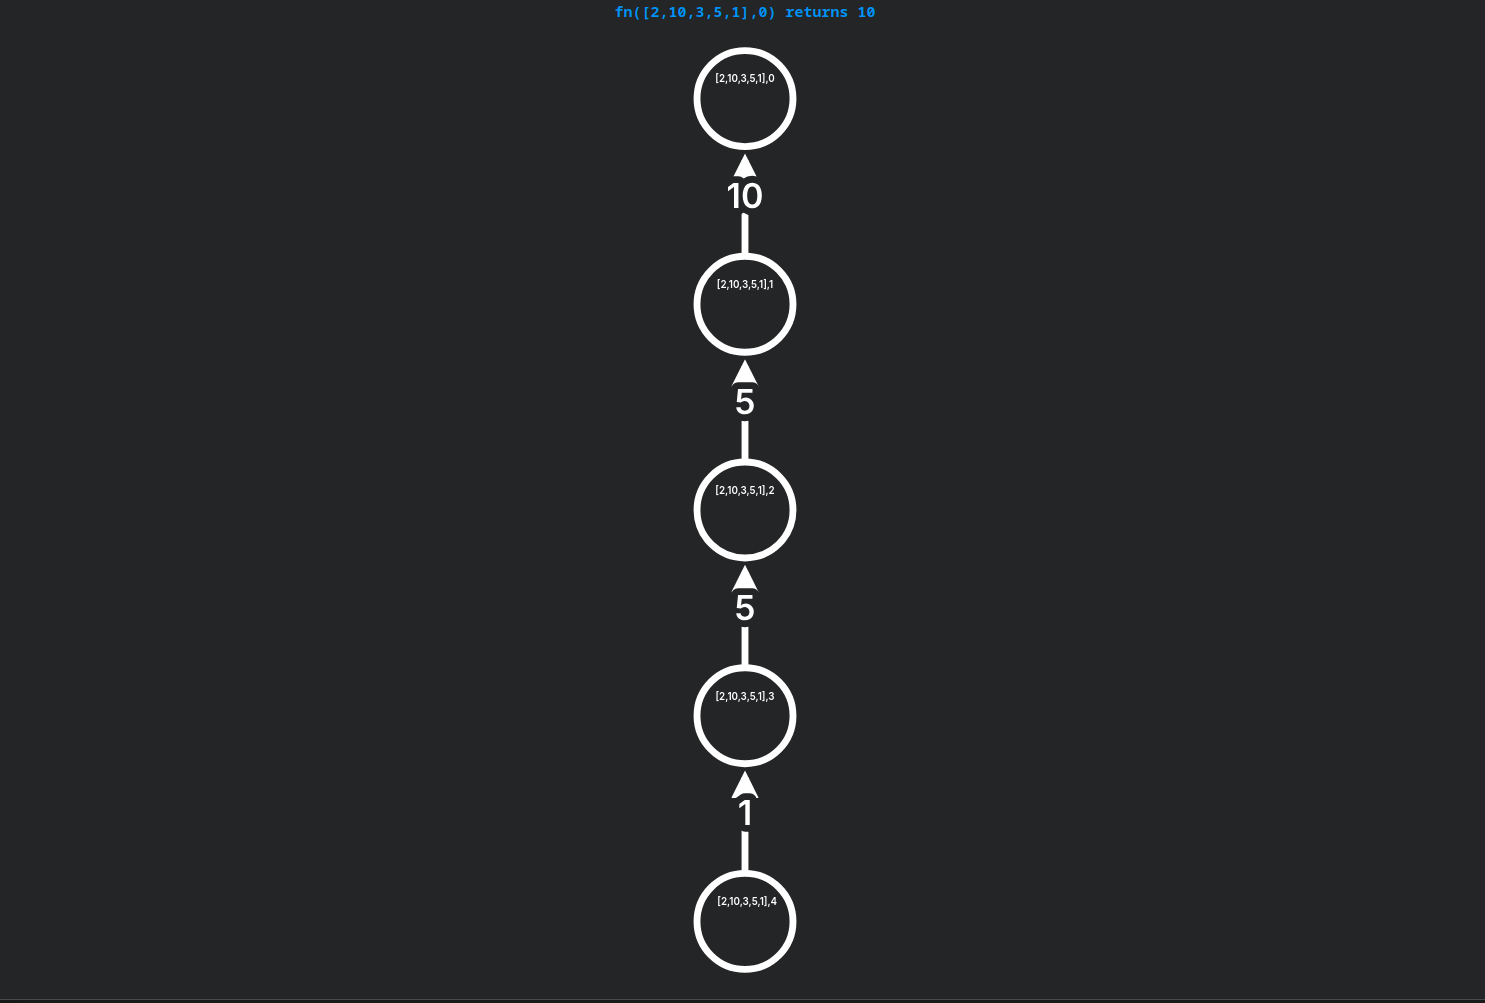

<div style="background-color: #f0f7ff; border-left: 4px solid #2563eb; padding: 15px; margin: 20px 0;">
<h3 style="margin-top: 0; color: #1e40af;">Złożoność czasowa</h3>
<p> Załóżmy, że $T(n)$ oznacza czas wykonania oraz, że operacje stałe kosztują $\mathcal{O}(1)$</p>
<p> Dla list o długości $n$ jedynym kosztem większym od $O(n)$ jes wywołanie rekurencji, zatem: $$ T(n) = T(n-1) + c,\quad T(1) = c_0$$</p>
<p>gdzie $c$ i $c_0$ koszty operacji stałej wewnątrz kroku rekurencyjnego.</p>
<p>Rozwijamy rekurencję:
$$
T(n)=T(n-1) + c = T(n-2) + 2c = ... = T(1) + (n-1)c = c_0 + (n-1)c \quad ,
$$
</p>
<p>zatem <strong>Złożoność obliczeniowa: </strong> $\mathcal{O}(n)$</p>
<h3 style="margin-top: 0; color: #1e40af;">Złożoność pamięciowa</h3>
<p>Na każdym poziomie rekurencji przechowywane są stałe informacje, zatem jedynym kosztem jest alokacja pamięci na stos wywołań, więc:</p>
<p><strong>Złożoność pamięciowa: $\mathcal{O}(n)$</stong></p>
</div>

# Zadanie 2 - Ślad rekurencji

<head>
  <link rel="stylesheet"
        href="https://cdnjs.cloudflare.com/ajax/libs/highlight.js/10.0.3/styles/default.min.css">
  <script src="https://cdnjs.cloudflare.com/ajax/libs/highlight.js/10.0.3/highlight.min.js"></script>
  <script>hljs.initHighlightingOnLoad();</script>
</head>
<body>
<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Narysuj rekurencyjny ślad wywołania power$(2,5)$ dla poniższego algorytmu:</p>
    <pre><code class="python">
        def power(x,n):
        """Compute the value x**n for integer n."""
        if n==0:
            return 1
        else
            return x*power(x, n-1)
    </code></pre>
</div>
</body>

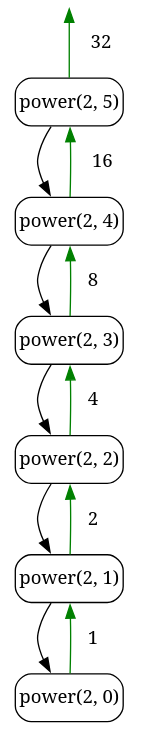

# Zadanie 3 - Największa i najmniejsza wartość w sekwencji

<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Napisz funkcję, która znajdzie najmniejszą i największą wartość w sekwencji</p>
</div>

In [37]:
def find_max_min_dc(seq, left=0, right=None):
    if right is None:
        right = len(seq) - 1
    # Pusta sekwencja
    if left > right:
        return None
    # Jednoelementowa sekwencja
    if left == right:
        return seq[left], seq[left]

    if left + 1 == right:
        if seq[left] < seq[right]:
            return seq[right], seq[left]
        else:
            return seq[left], seq[right]

    mid = (left + right) // 2
    max1, min1 = find_max_min_dc(seq, left, mid)
    max2, min2 = find_max_min_dc(seq, mid + 1, right)

    return (max1 if max1 > max2 else max2,
            min1 if min1 < min2 else min2)

# Weryfikacja algorytmu

In [38]:
def test_algorithm():
    # podstawowe przypadki
    assert find_max_min_dc([1]) == (1, 1)
    assert find_max_min_dc([5, 5, 5]) == (5, 5)
    assert find_max_min_dc([3, 2, 1]) == (3, 1)
    assert find_max_min_dc([2, 3, 1]) == (3, 1)
    assert find_max_min_dc([0, -1, -2, -3]) == (0, -3)
    assert find_max_min_dc([-10, 0, 10]) == (10, -10)

    # testy z wartościami powtarzającymi się
    assert find_max_min_dc([4, 2, 2, 4, 3]) == (4, 2)

    # testy z wartościami ujemnymi i zerem
    arr = [-5, -1, 0, -100]
    assert find_max_min_dc(arr) == (0, -100)

    # przypadek: pusta lista
    find_max_min_dc([])

    print("Wszystkie testy zakończone pomyślnie :)")
test_algorithm()

Wszystkie testy zakończone pomyślnie :)


# Zadanie 4


<div style="background-color: #f9fafb; border-left: 4px solid #6b7280; padding: 15px; margin: 20px 0;">
    <p><strong>Zadanie:</strong></p> Napisz funkcję liczącą iloczyn m i n tylko przy użyciu operatorów odejmowania o dodawania</p>
</div>

In [39]:
def multiplication(m,n, acc=0):
    if n == 0:
        return acc
    if n < 0:
        return multiplication(-m, -n, acc)
    # n > 0
    return multiplication(m, n - 1, acc + m)

# Weryfikacja algorytmu

In [40]:
def test_algorithm():
    assert multiplication(5, 0) == 0
    assert multiplication(5, 1) == 5
    assert multiplication(5, 3) == 15
    assert multiplication(7, 6) == 42
    assert multiplication(-4, 6) == -24
    assert multiplication(4, -6) == -24
    assert multiplication(-4, -6) == 24
    assert multiplication(0, 99) == 0
    assert multiplication(1, 999) == 999
    print("Wszystkie testy zakończone pomyślnie :)")

test_algorithm()

Wszystkie testy zakończone pomyślnie :)


# Zadanie 5 - Palindrom

In [41]:
def is_palindrome(s):
    s = ''.join(ch.lower() for ch in s if ch.isalnum())
    if len(s) <= 1:
        return True
    return s[0] == s[-1] and is_palindrome(s[1:-1])

In [42]:
def test_algorithm():
    assert is_palindrome("") == True
    assert is_palindrome("a") == True
    assert is_palindrome("aba") == True
    assert is_palindrome("abba") == True
    assert is_palindrome("A man, a plan, a canal: Panama") == True
    assert is_palindrome("No 'x' in Nixon") == True
    assert is_palindrome("hello") == False
    assert is_palindrome("abcbaX") == False

    print("Wszystkie testy zakończone pomyślnie :)")

test_algorithm()

Wszystkie testy zakończone pomyślnie :)


# Zadanie 6

In [43]:
def find(path, filename):
    results = []
    try:
        for entry in os.listdir(path):
            full = os.path.join(path, entry)
            if os.path.isfile(full) and entry == filename:
                results.append(full)
            elif os.path.isdir(full):
                results += find(full, filename)  # rekurencja
    except PermissionError:
        pass  # pomijamy katalogi bez dostępu
    return results

In [44]:
files = find('foo', 'bar1.txt')
print(files)

['foo/foo2/bar1.txt', 'foo/bar1.txt']
